In [52]:
from scipy.io import loadmat

data = loadmat('tv_lqr_data.mat')

X = data['X']   # (16574, 6)
U = data['U']   # (16574, 3)
t = data['t'].flatten()

In [53]:
import numpy as np
from sklearn.linear_model import Ridge

# X: (N, 6)  -> delta x
# U: (N, 3)

alpha = 1e-6

model = Ridge(alpha=alpha, fit_intercept=False)
model.fit(X, U)

K = -model.coef_   # (3, 6)

print("Recovered K:\n", K)

Recovered K:
 [[-5.78375987  0.34401342 -0.09914137 -0.41909554  3.39988329 -0.68787958]
 [-0.14353023 -1.44180238 -0.27871231 -0.86014495 -1.32197091  1.71029911]
 [-0.2049695   0.29375543 -0.27650321  0.06420203 -1.15598628 -0.38052958]]


In [54]:
U_pred = -X @ K.T
error = np.linalg.norm(U - U_pred) / np.linalg.norm(U)
print(error)

0.9086388062825671


In [55]:
print(X.shape, U.shape, t.shape)

(16574, 6) (16574, 3) (16574,)


In [56]:
print(np.mean(np.linalg.norm(X, axis=1)))

4.652846518709197e-06


In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Predicted control using learned K
U_pred = -X @ K.T   # (N, 3)

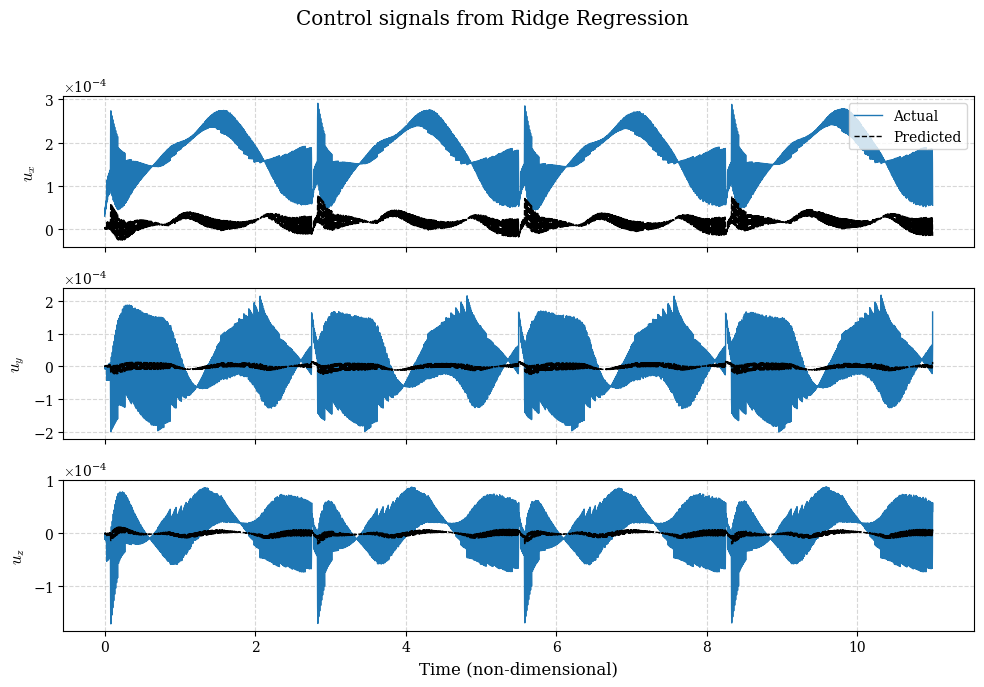

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],   
    "mathtext.fontset": "cm",         
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
})

# Labels
labels = [r'$u_x$', r'$u_y$', r'$u_z$']

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(t, U[:, i], label='Actual', linewidth=1)
    ax.plot(t, U_pred[:, i], 'k--', label='Predicted', linewidth=1)

    ax.set_ylabel(labels[i])
    ax.grid(True, linestyle='--', alpha=0.5)

    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-4, -4))
    ax.yaxis.set_major_formatter(formatter)
    
    ax.yaxis.get_offset_text().set_size(10)

    if i == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel(r'Time (non-dimensional)')

fig.suptitle('Control signals from Ridge Regression')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

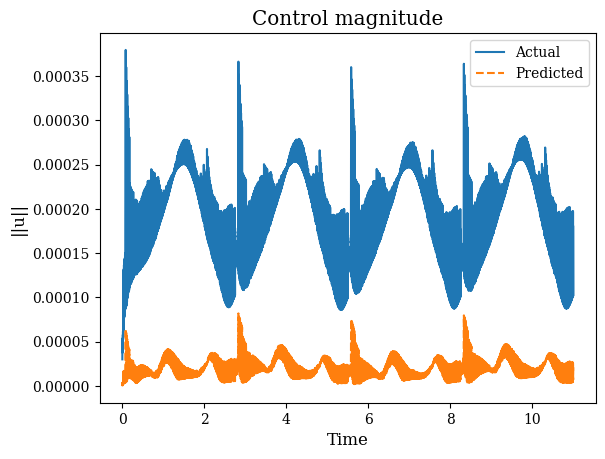

In [60]:
u_norm = np.linalg.norm(U, axis=1)
u_pred_norm = np.linalg.norm(U_pred, axis=1)

plt.figure()
plt.plot(t, u_norm, label='Actual')
plt.plot(t, u_pred_norm, '--', label='Predicted')
plt.xlabel('Time')
plt.ylabel('||u||')
plt.title('Control magnitude')
plt.legend()
plt.show()

In [61]:
data = loadmat('full_lqr_data.mat')

X_new = data['X']   # (16574, 6)
U_new = data['U']   # (16574, 3)
t_new = data['t'].flatten()

In [62]:
# X: (N, 6)  -> delta x
# U: (N, 3)

alpha = 1e-6

model = Ridge(alpha=alpha, fit_intercept=False)
model.fit(X_new, U_new)

K = -model.coef_   # (3, 6)

print("Recovered K:\n", K)

Recovered K:
 [[-27.26031759   2.29022806  -1.77267217  -2.44600657   8.60628572
   -1.84655279]
 [ -1.91237551  -8.03276411  -1.27988832  -3.83629771  -4.59346714
    8.61792453]
 [ -1.81611044   1.48110076  -1.4562835    0.25977976  -4.38253886
   -2.28680961]]


In [63]:
U_pred_new = -X_new @ K.T

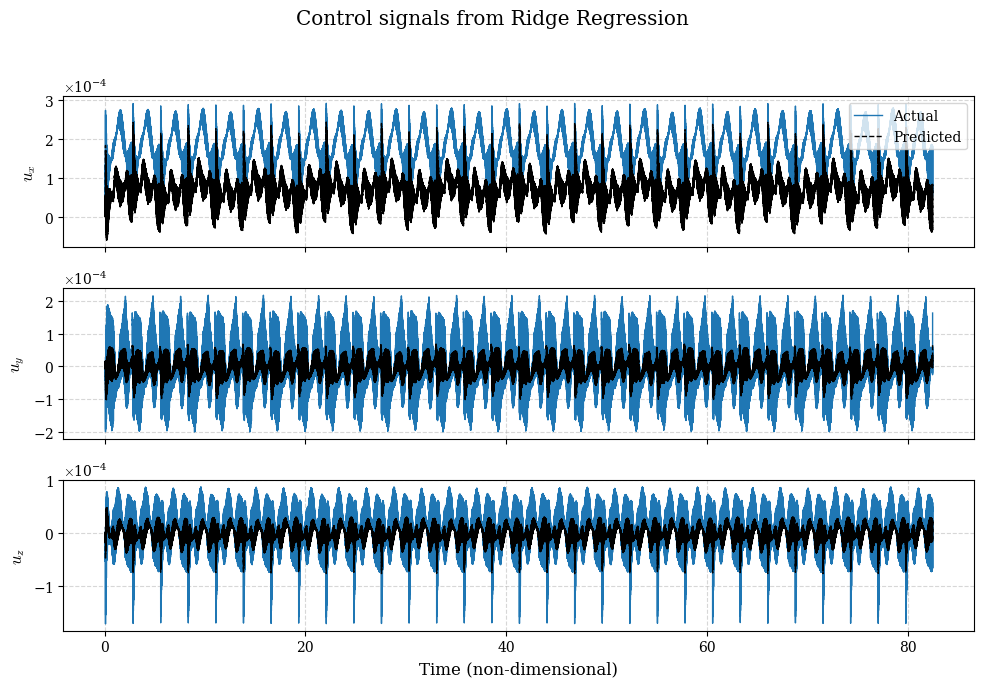

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],   
    "mathtext.fontset": "cm",         
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
})

# Labels
labels = [r'$u_x$', r'$u_y$', r'$u_z$']

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(t_new, U_new[:, i], label='Actual', linewidth=1)
    ax.plot(t_new, U_pred_new[:, i], 'k--', label='Predicted', linewidth=1)

    ax.set_ylabel(labels[i])
    ax.grid(True, linestyle='--', alpha=0.5)

    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-4, -4))
    ax.yaxis.set_major_formatter(formatter)
    
    ax.yaxis.get_offset_text().set_size(10)

    if i == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel(r'Time (non-dimensional)')

fig.suptitle('Control signals from Ridge Regression')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('control_plot.png', dpi=300, bbox_inches='tight')
plt.show()

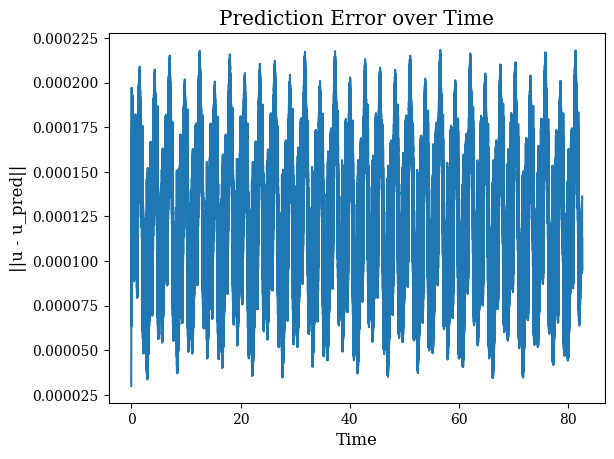

In [65]:
error_time = np.linalg.norm(U_new - U_pred_new, axis=1)

plt.figure()
plt.plot(t_new, error_time)
plt.xlabel('Time')
plt.ylabel('||u - u_pred||')
plt.title('Prediction Error over Time')
plt.show()

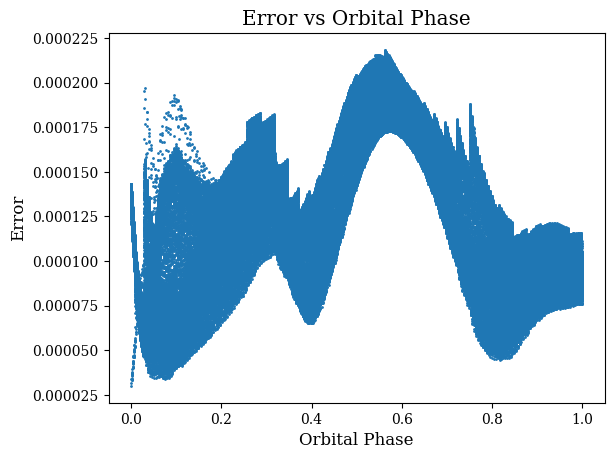

In [66]:
T = 2.7499

phase = (t_new % T) / T   # if you know orbital period T

plt.figure()
plt.scatter(phase, error_time, s=1)
plt.xlabel('Orbital Phase')
plt.ylabel('Error')
plt.title('Error vs Orbital Phase')
plt.show()